## Diabetes prediction (local notebook + Streamlit)

This notebook trains a neural network on the Pima Indians diabetes dataset and produces:

- A trained model saved to `E:\Diabetes Pima Indians Data\artifacts\diabetes_model.keras`
- A fitted scaler saved to `E:\Diabetes Pima Indians Data\artifacts\scaler.pkl`
- EDA plots saved to `E:\Diabetes Pima Indians Data\artifacts\eda\` for display inside Streamlit

After running the notebook, start the app with:

```bash
streamlit run app.py
```


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [65]:
import pandas as pd

# Local Windows path (run notebook locally)
DATA_PATH = r"E:\Diabetes Pima Indians Data\Dataset\diabetes.csv"

# Your local file already contains headers.
df = pd.read_csv(DATA_PATH)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Load data + EDA (saved for Streamlit)

- This notebook reads the dataset from your local path:
  `E:\Diabetes Pima Indians Data\Dataset\diabetes.csv`
- The next EDA cell generates plots (class balance, correlations, distributions, boxplots) and **saves PNGs** to:
  `E:\Diabetes Pima Indians Data\artifacts\eda\`

Those saved images are displayed in the Streamlit app under the **Dataset** tab.


In [66]:
# === EDA: save visualizations for Streamlit ===
import os

import matplotlib.pyplot as plt
import seaborn as sns

ARTIFACTS_DIR = r"E:\Diabetes Pima Indians Data\artifacts"
EDA_DIR = os.path.join(ARTIFACTS_DIR, "eda")
os.makedirs(EDA_DIR, exist_ok=True)

# Basic cleaning note: many Pima versions encode missing medical values as 0.
# This notebook keeps the original approach, but EDA plots still help explain distributions.

# 1) Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Outcome distribution")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "01_outcome_distribution.png"), dpi=200)
plt.close()

# 2) Correlation heatmap
plt.figure(figsize=(10, 8))
cor = df.corr(numeric_only=True)
sns.heatmap(cor, cmap="coolwarm", center=0, square=True)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "02_correlation_heatmap.png"), dpi=200)
plt.close()

# 3) Feature histograms
num_cols = [c for c in df.columns if c != "Outcome"]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], bins=30, kde=True, ax=ax)
    ax.set_title(c)
plt.suptitle("Feature distributions", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(EDA_DIR, "03_feature_distributions.png"), dpi=200)
plt.close(fig)

# 4) Boxplots by outcome
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for ax, c in zip(axes, num_cols):
    sns.boxplot(x="Outcome", y=c, data=df, ax=ax)
    ax.set_title(c)
plt.suptitle("Features by outcome", y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(EDA_DIR, "04_boxplots_by_outcome.png"), dpi=200)
plt.close(fig)

print("Saved EDA graphs to:", EDA_DIR)


Saved EDA graphs to: E:\Diabetes Pima Indians Data\artifacts\eda


In [67]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [69]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, input_shape=(8,), activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, batch_size=10, validation_split=0.1)


Epoch 1/100


c:\Users\elzok\.conda\envs\py310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5688 - loss: 0.6991 - val_accuracy: 0.6774 - val_loss: 0.7004
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6866 - loss: 0.6202 - val_accuracy: 0.7258 - val_loss: 0.6389
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7174 - loss: 0.5728 - val_accuracy: 0.7258 - val_loss: 0.5872
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7337 - loss: 0.5416 - val_accuracy: 0.7419 - val_loss: 0.5444
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7391 - loss: 0.5176 - val_accuracy: 0.7258 - val_loss: 0.5228
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.5003 - val_accuracy: 0.7419 - val_loss: 0.5034
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7554 - loss: 0.4866 - val_accuracy: 0.7419 - val_loss: 0.4824
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7572 - loss: 0.4755 - val_accuracy: 0.7419 - val_loss: 0.4

In [70]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy: {:.2f}%".format(accuracy * 100))


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7013 - loss: 0.6539 
Test Accuracy: 70.13%


In [71]:
# Import necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load the dataset from your local Windows path (run notebook locally)
DATA_PATH = r"E:\Diabetes Pima Indians Data\Dataset\diabetes.csv"

# Your local file already contains headers.
df = pd.read_csv(DATA_PATH)

# Display the first few rows of the dataset
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Model architecture (final model used)

This notebook builds a dense neural network for tabular data. The model used for predictions/saving is the **latest `model = Sequential()`** defined below.

| Layer | Details | Output |
|---|---|---|
| Input | 8 features | (None, 8) |
| Dense | 128 units, ReLU | (None, 128) |
| Dense | 64 units, ReLU | (None, 64) |
| Dense | 1 unit, Sigmoid | (None, 1) |

**Output interpretation:** sigmoid gives a probability in \([0,1]\). This notebook uses a threshold of **0.50** to classify diabetes vs no diabetes.


In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build the model
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary classification

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/50


c:\Users\elzok\.conda\envs\py310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6498 - loss: 0.6309 - val_accuracy: 0.7468 - val_loss: 0.5553
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7704 - loss: 0.5055 - val_accuracy: 0.7922 - val_loss: 0.5026
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7638 - loss: 0.4653 - val_accuracy: 0.7857 - val_loss: 0.4987
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7687 - loss: 0.4463 - val_accuracy: 0.7662 - val_loss: 0.5059
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7818 - loss: 0.4389 - val_accuracy: 0.7532 - val_loss: 0.5188
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7899 - loss: 0.4310 - val_accuracy: 0.7662 - val_loss: 0.5187
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7899 - loss: 0.4250 - val_accuracy: 0.7597 - val_loss: 0.5228
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7883 - loss: 0.4205 - val_accuracy: 0.7597 - val_loss: 0.5225
Ep

In [73]:
# === Cloud-friendly sklearn fallback model (no TensorFlow needed) ===
# Streamlit Cloud may not support TensorFlow on the default Python version.
# This trains a lightweight LogisticRegression on the SAME train/test split.

import os
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

ARTIFACTS_DIR = r"E:\Diabetes Pima Indians Data\artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# IMPORTANT: X_train and X_test are already scaled earlier in the notebook.
# We'll train on scaled features and save the model only.

sk_model = LogisticRegression(max_iter=2000, class_weight="balanced")
sk_model.fit(X_train, y_train)

proba = sk_model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print("[sklearn] Test accuracy:", round(accuracy_score(y_test, pred), 4))
print("[sklearn] Test balanced accuracy:", round(balanced_accuracy_score(y_test, pred), 4))
print("[sklearn] Test ROC-AUC:", round(roc_auc_score(y_test, proba), 4))

SK_MODEL_PATH = os.path.join(ARTIFACTS_DIR, "sk_model.joblib")
joblib.dump(sk_model, SK_MODEL_PATH)
print("Saved sklearn fallback model to:", SK_MODEL_PATH)


[sklearn] Test accuracy: 0.6948
[sklearn] Test balanced accuracy: 0.698
[sklearn] Test ROC-AUC: 0.8134
Saved sklearn fallback model to: E:\Diabetes Pima Indians Data\artifacts\sk_model.joblib


In [74]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, y_test)

# Print accuracy
print(f"Test Accuracy: {accuracy * 100:.2f}%")


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7338 - loss: 0.6539 
Test Accuracy: 73.38%


In [75]:
# Predict the outcomes for the test set
y_pred = model.predict(X_test)

# Convert predictions to binary values (0 or 1)
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate accuracy score
from sklearn.metrics import accuracy_score
print(f"Accuracy: {accuracy_score(y_test, y_pred_binary) * 100:.2f}%")



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy: 73.38%


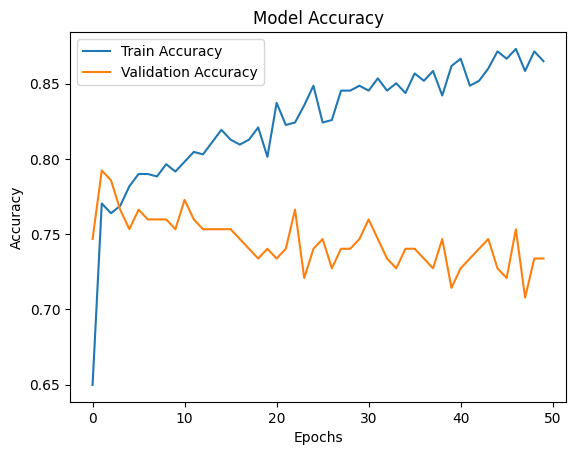

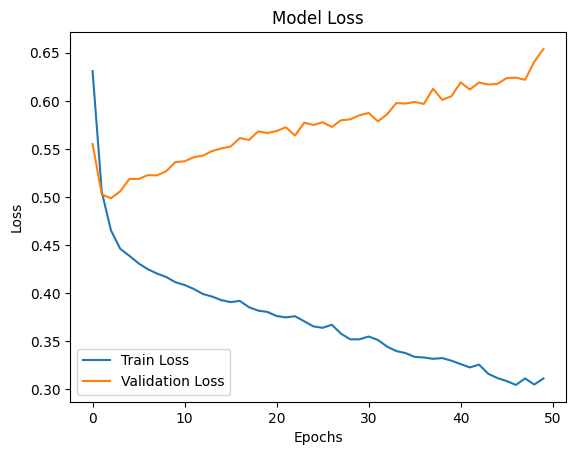

In [76]:
import matplotlib.pyplot as plt

# Plot training history (accuracy and loss)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [77]:
# Save the trained model + scaler for local Streamlit inference
import os
import joblib

ARTIFACTS_DIR = r"E:\Diabetes Pima Indians Data\artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(ARTIFACTS_DIR, "diabetes_model.keras")
SCALER_PATH = os.path.join(ARTIFACTS_DIR, "scaler.pkl")

model.save(MODEL_PATH)         # native Keras format
joblib.dump(scaler, SCALER_PATH)

print("Saved model to:", MODEL_PATH)
print("Saved scaler to:", SCALER_PATH)


Saved model to: E:\Diabetes Pima Indians Data\artifacts\diabetes_model.keras
Saved scaler to: E:\Diabetes Pima Indians Data\artifacts\scaler.pkl


In [78]:
# === Final evaluation metrics (test set) ===
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# Probability predictions
y_proba = model.predict(X_test, verbose=0).ravel()

# Default threshold
y_pred = (y_proba >= 0.5).astype(int)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred), 4))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print()
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print()
print("Classification report:\n")
print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))


Test accuracy: 0.7338
Test balanced accuracy: 0.7323
Test ROC-AUC: 0.7802

Confusion matrix:
 [[73 26]
 [15 40]]

Classification report:

              precision    recall  f1-score   support

 No diabetes       0.83      0.74      0.78        99
    Diabetes       0.61      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



## What to run (local)

1) Run the notebook from top to bottom.

- The **EDA cell** saves graphs to:
  `E:\Diabetes Pima Indians Data\artifacts\eda\`
- The **artifacts cell** saves the trained model + scaler to:
  `E:\Diabetes Pima Indians Data\artifacts\diabetes_model.keras` and `E:\Diabetes Pima Indians Data\artifacts\scaler.pkl`

2) Start the Streamlit app from the project folder:

```bash
streamlit run app.py
```

In Streamlit, open the **Dataset** tab to see the saved EDA plots.
